# 🤖 TFT Training v3 — Multi-country Electricity Forecasting

**Mục tiêu:** Train mô hình **Temporal Fusion Transformer (TFT)** trên bộ dữ liệu đa quốc gia  
và lưu checkpoint để làm **pretrained model** cho bước Transfer Learning sang Việt Nam.

---
| Mục | Thông tin |
|---|---|
| Dataset | `tft_premodel_dataset_EDA.csv` (34,614 rows × 30 cols) |
| Entities | 20 quốc gia |
| Series target | Coal, Gas, Hydro, Solar, Wind, Bioenergy, Nuclear, Other Fossil, Other Renewables |
| Encoder length | 24 tháng |
| Prediction length | 6 tháng |
| Checkpoint output | `checkpoint/tft_v3_best.ckpt` |

In [18]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — IMPORTS & DEVICE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings, os, json, copy, shutil
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateMonitor
)
from lightning.pytorch.loggers import TensorBoardLogger

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ PyTorch  : {torch.__version__}')
print(f'   Device   : {DEVICE}',
      f'({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else '')
print(f'   Lightning : {pl.__version__}')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR  = Path(r'C:\Users\ADMIN\Downloads\MODEL_TFT')
DATA_PATH = BASE_DIR / 'data' / 'processed' / 'training_data' / 'tft_premodel_dataset_EDA.csv'
CKPT_DIR  = BASE_DIR / 'checkpoint'
LOG_DIR   = BASE_DIR / 'lightning_logs' / 'tft_v3'
CKPT_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
print(f'   Data      : {DATA_PATH}')
print(f'   Checkpoint: {CKPT_DIR}')

✅ PyTorch  : 2.4.1+cpu
   Device   : cpu 
   Lightning : 2.6.1
   Data      : C:\Users\ADMIN\Downloads\MODEL_TFT\data\processed\training_data\tft_premodel_dataset_EDA.csv
   Checkpoint: C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint


In [19]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — HYPERPARAMETERS & CONFIG
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CFG = dict(
    # ── Dataset ───────────────────────────────────────────────────────────────
    max_encoder_length    = 24,
    max_prediction_length = 6,
    min_series_length     = 30,   # encoder + prediction
    val_cutoff_months     = 12,   # dùng 12 tháng cuối làm validation

    # ── Model ─────────────────────────────────────────────────────────────────
    hidden_size           = 128,
    attention_head_size   = 4,
    dropout               = 0.15,
    hidden_continuous_size= 32,
    lstm_layers           = 2,

    # ── Training ──────────────────────────────────────────────────────────────
    learning_rate         = 3e-4,  # adamw cần LR nhỏ hơn ranger
    batch_size            = 64,
    max_epochs            = 80,
    gradient_clip_val     = 0.1,
    patience              = 12,    # EarlyStopping
    num_workers           = 0,     # Windows: giữ 0

    # ── Quantiles ─────────────────────────────────────────────────────────────
    loss_quantiles        = [0.1, 0.25, 0.5, 0.75, 0.9],

    # ── Seed ──────────────────────────────────────────────────────────────────
    seed                  = 42,
)

pl.seed_everything(CFG['seed'], workers=True)
print('📋 Cấu hình hiện tại:')
for k, v in CFG.items():
    print(f'   {k:<28}: {v}')

Seed set to 42
Seed set to 42


📋 Cấu hình hiện tại:
   max_encoder_length          : 24
   max_prediction_length       : 6
   min_series_length           : 30
   val_cutoff_months           : 12
   hidden_size                 : 128
   attention_head_size         : 4
   dropout                     : 0.15
   hidden_continuous_size      : 32
   lstm_layers                 : 2
   learning_rate               : 0.0003
   batch_size                  : 64
   max_epochs                  : 80
   gradient_clip_val           : 0.1
   patience                    : 12
   num_workers                 : 0
   loss_quantiles              : [0.1, 0.25, 0.5, 0.75, 0.9]
   seed                        : 42


In [20]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — LOAD & LỌC DỮ LIỆU
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df_raw = pd.read_csv(DATA_PATH)
df_raw['date'] = pd.to_datetime(df_raw['date'])
print(f'Raw shape: {df_raw.shape}')
print(f'All series: {sorted(df_raw["series"].unique())}')

# ── Chỉ giữ các series là nguồn điện thực sự ──────────────────────────────────
# Loại bỏ: aggregate, price, CO2, Demand
TARGET_SERIES = [
    'Coal', 'Gas', 'Hydro', 'Solar', 'Wind',
    'Bioenergy', 'Nuclear', 'Other Fossil', 'Other Renewables',
]
df = df_raw[df_raw['series'].isin(TARGET_SERIES)].copy()
print(f'\nSau lọc series: {df.shape}')

# ── Fill NaN từ lag features ──────────────────────────────────────────────────
lag_cols = ['gen_lag_1','gen_lag_3','gen_lag_12',
            'roll_mean_3','roll_mean_6','roll_std_3','roll_max_6',
            'yoy_change','prec_lag_1','prec_lag_2']
for col in lag_cols:
    if col in df.columns:
        df[col] = df.groupby(['entity','series'])[col].transform(
            lambda x: x.fillna(method='bfill').fillna(0))

# ── Tạo prec_zscore nếu chưa có ──────────────────────────────────────────────
if 'prec_zscore' not in df.columns:
    mu  = df.groupby('entity')['precipitation'].transform('mean')
    std = df.groupby('entity')['precipitation'].transform('std').replace(0, 1)
    df['prec_zscore'] = (df['precipitation'] - mu) / std
    print('  prec_zscore: created from precipitation')

# ── Lọc series đủ độ dài ──────────────────────────────────────────────────────
counts  = df.groupby(['entity','series']).size()
valid   = counts[counts >= CFG['min_series_length']].reset_index()[['entity','series']]
df      = df.merge(valid, on=['entity','series'])
print(f'Sau lọc độ dài (>={CFG["min_series_length"]}m): {df.shape}')
print(f'Groups hợp lệ: {df.groupby(["entity","series"]).ngroups}')

# ── Tạo time_idx liên tục per group ──────────────────────────────────────────
df = df.sort_values(['entity','series','date'])
df['time_idx'] = df.groupby(['entity','series'])['date'].rank(method='dense').astype(int) - 1

print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'Date range    : {df["date"].min().date()} → {df["date"].max().date()}')

Raw shape: (34614, 30)
All series: ['Bioenergy', 'CO2 intensity', 'Clean', 'Coal', 'Day-ahead electricity price', 'Demand', 'Fossil', 'Gas', 'Gas and Other Fossil', 'Hydro', 'Hydro, Bioenergy and Other Renewables', 'Net Imports', 'Nuclear', 'Other Fossil', 'Other Renewables', 'Renewables', 'Solar', 'Total Generation', 'Total emissions', 'Wind', 'Wind and Solar']

Sau lọc series: (13878, 30)
Sau lọc độ dài (>=30m): (13859, 30)
Groups hợp lệ: 151

Missing values: 0
Date range    : 2018-01-01 → 2025-12-01


In [21]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — TRAIN / VALIDATION SPLIT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Dùng time_idx để cắt: toàn bộ data nhưng chỉ predict phần cuối
training_cutoff = int(df['time_idx'].max()) - CFG['val_cutoff_months']
val_cutoff_date = df['date'].max() - pd.DateOffset(months=CFG['val_cutoff_months'])

print(f'📅 Train/Val Split:')
print(f'   training_cutoff (time_idx) : {training_cutoff}')
print(f'   val_cutoff_date            : {val_cutoff_date.date()}')
print(f'   Train rows                 : {(df["time_idx"] <= training_cutoff).sum():,}')
print(f'   Val rows                   : {(df["time_idx"] >  training_cutoff).sum():,}')

📅 Train/Val Split:
   training_cutoff (time_idx) : 83
   val_cutoff_date            : 2024-12-01
   Train rows                 : 12,451
   Val rows                   : 1,408


In [22]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — TimeSeriesDataSet
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

STATIC_CATEGORICALS = ['entity']

TIME_VARYING_KNOWN_REALS = [
    'time_idx',
    'month', 'month_sin', 'month_cos', 'quarter', 'year',
    'solar',        # bức xạ mặt trời — biết trước
    'temperature',  # nhiệt độ — dự báo được
    'humidity',     # độ ẩm — dự báo được
]

TIME_VARYING_UNKNOWN_REALS = [
    'generation_TWh',       # target (autoregressive)
    'precipitation',
    'log_precipitation',
    'prec_zscore',
    'gen_lag_1',
    'gen_lag_3',
    'gen_lag_12',
    'roll_mean_3',
    'roll_mean_6',
    'roll_std_3',
    'roll_max_6',
    'yoy_change',
    'temp_anomaly',
    'solar_norm',
    'prec_lag_1',
    'prec_lag_2',
]

# ── Kiểm tra columns ──────────────────────────────────────────────────────────
all_needed = (STATIC_CATEGORICALS + TIME_VARYING_KNOWN_REALS +
              TIME_VARYING_UNKNOWN_REALS + ['series'])
missing_cols = [c for c in all_needed if c not in df.columns]
if missing_cols:
    print(f'⚠️  Thiếu columns: {missing_cols}')
else:
    print('✅ Tất cả columns đều có mặt')

# ── Tạo training dataset ──────────────────────────────────────────────────────
print('⏳ Đang tạo TimeSeriesDataSet...')
training = TimeSeriesDataSet(
    df[df['time_idx'] <= training_cutoff],
    time_idx                         = 'time_idx',
    target                           = 'generation_TWh',
    group_ids                        = ['entity', 'series'],
    min_encoder_length               = CFG['max_encoder_length'] // 2,
    max_encoder_length               = CFG['max_encoder_length'],
    min_prediction_length            = 1,
    max_prediction_length            = CFG['max_prediction_length'],
    static_categoricals              = STATIC_CATEGORICALS,
    static_reals                     = [],
    time_varying_known_categoricals  = ['series'],
    time_varying_known_reals         = TIME_VARYING_KNOWN_REALS,
    time_varying_unknown_categoricals= [],
    time_varying_unknown_reals       = TIME_VARYING_UNKNOWN_REALS,
    target_normalizer                = GroupNormalizer(
        groups         = ['entity', 'series'],
        transformation = 'softplus',
    ),
    add_relative_time_idx            = True,
    add_target_scales                = True,
    add_encoder_length               = True,
    allow_missing_timesteps          = True,
)
print(f'✅ Training dataset : {len(training):,} samples')

# ── Validation dataset ────────────────────────────────────────────────────────
validation = TimeSeriesDataSet.from_dataset(
    training, df, predict=True, stop_randomization=True
)
print(f'✅ Validation dataset: {len(validation):,} samples')

✅ Tất cả columns đều có mặt
⏳ Đang tạo TimeSeriesDataSet...
✅ Training dataset : 13,206 samples
✅ Validation dataset: 151 samples


In [23]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — DATALOADERS + SANITY CHECK
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
train_loader = training.to_dataloader(
    train      = True,
    batch_size = CFG['batch_size'],
    num_workers= CFG['num_workers'],
)
val_loader = validation.to_dataloader(
    train      = False,
    batch_size = CFG['batch_size'] * 2,
    num_workers= CFG['num_workers'],
)

# Sanity check một batch
x, y = next(iter(train_loader))
print('✅ DataLoaders sẵn sàng')
print(f'   Encoder shape : {x["encoder_cont"].shape}   (batch, time, features)')
print(f'   Decoder shape : {x["decoder_cont"].shape}')
print(f'   Target shape  : {y[0].shape}')
print(f'   Train batches : {len(train_loader)} batch/epoch')
print(f'   Val   batches : {len(val_loader)} batch/epoch')

✅ DataLoaders sẵn sàng
   Encoder shape : torch.Size([64, 24, 29])   (batch, time, features)
   Decoder shape : torch.Size([64, 6, 29])
   Target shape  : torch.Size([64, 6])
   Train batches : 206 batch/epoch
   Val   batches : 2 batch/epoch


In [24]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — BUILD TFT MODEL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model = TemporalFusionTransformer.from_dataset(
    training,
    # Architecture
    hidden_size            = CFG['hidden_size'],
    attention_head_size    = CFG['attention_head_size'],
    dropout                = CFG['dropout'],
    hidden_continuous_size = CFG['hidden_continuous_size'],
    lstm_layers            = CFG['lstm_layers'],
    # Loss
    loss                   = QuantileLoss(quantiles=CFG['loss_quantiles']),
    # Optimizer — dùng 'adamw' (có sẵn trong PyTorch, không cần cài thêm)
    # NOTE: 'ranger' cần pip install pytorch-optimizer
    learning_rate          = CFG['learning_rate'],
    optimizer              = 'adamw',
    # Logging
    log_interval           = 10,
    log_val_interval       = 1,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ TFT Model built')
print(f'   Optimizer      : AdamW')
print(f'   Parameters     : {n_params:,} ({n_params/1e6:.2f}M)')
print(f'   Hidden size    : {CFG["hidden_size"]}')
print(f'   Attention heads: {CFG["attention_head_size"]}')
print(f'   LSTM layers    : {CFG["lstm_layers"]}')
print(f'   Loss           : QuantileLoss {CFG["loss_quantiles"]}')

✅ TFT Model built
   Optimizer      : AdamW
   Parameters     : 1,558,792 (1.56M)
   Hidden size    : 128
   Attention heads: 4
   LSTM layers    : 2
   Loss           : QuantileLoss [0.1, 0.25, 0.5, 0.75, 0.9]


In [25]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — LEARNING RATE FINDER (tùy chọn)
# Đặt RUN_LR_FINDER = True để tìm LR tốt nhất trước khi train
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RUN_LR_FINDER = False

if RUN_LR_FINDER:
    print('🔎 Đang chạy LR Finder...')
    lr_trainer = pl.Trainer(
        accelerator       = 'gpu' if DEVICE == 'cuda' else 'cpu',
        gradient_clip_val = CFG['gradient_clip_val'],
        enable_progress_bar = True,
    )
    lr_model  = copy.deepcopy(model)
    lr_finder = lr_trainer.tuner.lr_find(
        lr_model,
        train_dataloaders = train_loader,
        val_dataloaders   = val_loader,
        min_lr            = 1e-5,
        max_lr            = 1.0,
        num_training      = 100,
    )
    suggested_lr = lr_finder.suggestion()
    print(f'\n🎯 Suggested LR: {suggested_lr:.2e}')
    fig = lr_finder.plot(suggest=True)
    plt.title('LR Finder')
    plt.show()
    # Cập nhật model với LR mới
    CFG['learning_rate'] = suggested_lr
    model.hparams.learning_rate = suggested_lr
    print(f'✅ LR cập nhật: {suggested_lr:.2e}')
else:
    print(f'⏭️  Skip LR Finder — dùng LR = {CFG["learning_rate"]:.2e}')
    print('   (Đặt RUN_LR_FINDER = True để kích hoạt)')

⏭️  Skip LR Finder — dùng LR = 3.00e-04
   (Đặt RUN_LR_FINDER = True để kích hoạt)


In [26]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — CALLBACKS & TRAINER
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── ModelCheckpoint: lưu top 3 model tốt nhất + latest ───────────────────────
checkpoint_callback = ModelCheckpoint(
    dirpath      = str(CKPT_DIR),
    filename     = 'tft_v3_{epoch:02d}_{val_loss:.4f}',
    monitor      = 'val_loss',
    mode         = 'min',
    save_top_k   = 3,
    save_last    = True,
    verbose      = True,
)

# ── EarlyStopping: dừng khi val_loss không cải thiện sau `patience` epochs ───
early_stop_callback = EarlyStopping(
    monitor   = 'val_loss',
    patience  = CFG['patience'],  # 12 epochs
    min_delta = 1e-4,
    mode      = 'min',
    verbose   = True,
)

# ── LearningRateMonitor: log LR vào TensorBoard ──────────────────────────────
lr_monitor = LearningRateMonitor(logging_interval='epoch')

# ── Logger ────────────────────────────────────────────────────────────────────
logger = TensorBoardLogger(
    save_dir = str(BASE_DIR / 'lightning_logs'),
    name     = 'tft_v3',
    version  = 'run_1',
)

# ── Trainer ───────────────────────────────────────────────────────────────────
trainer = pl.Trainer(
    accelerator          = 'gpu' if DEVICE == 'cuda' else 'cpu',
    devices              = 1,
    max_epochs           = CFG['max_epochs'],
    gradient_clip_val    = CFG['gradient_clip_val'],
    callbacks            = [checkpoint_callback, early_stop_callback, lr_monitor],
    logger               = logger,
    enable_progress_bar  = True,
    enable_model_summary = True,
    log_every_n_steps    = 5,
    precision            = '16-mixed' if DEVICE == 'cuda' else '32',
)

print('✅ Trainer sẵn sàng')
print(f'   Max epochs      : {CFG["max_epochs"]}')
print(f'   EarlyStopping   : patience = {CFG["patience"]} epochs')
print(f'   Gradient clip   : {CFG["gradient_clip_val"]}')
print(f'   Precision       : {"16-mixed" if DEVICE=="cuda" else "32-bit"}')
print(f'   Checkpoint dir  : {CKPT_DIR}')
print(f'   TensorBoard     : {BASE_DIR / "lightning_logs"}')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✅ Trainer sẵn sàng
   Max epochs      : 80
   EarlyStopping   : patience = 12 epochs
   Gradient clip   : 0.1
   Precision       : 32-bit
   Checkpoint dir  : C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint
   TensorBoard     : C:\Users\ADMIN\Downloads\MODEL_TFT\lightning_logs


In [27]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — TRAINING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('🚀 Bắt đầu training...')
print('=' * 65)

trainer.fit(
    model,
    train_dataloaders = train_loader,
    val_dataloaders   = val_loader,
)

print('\n' + '=' * 65)
print('✅ Training hoàn tất!')
print(f'   Best val_loss   : {checkpoint_callback.best_model_score:.6f}')
print(f'   Best checkpoint : {checkpoint_callback.best_model_path}')
print(f'   Dừng tại epoch  : {trainer.current_epoch}')

🚀 Bắt đầu training...


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    225 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.9 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 34.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  321 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  118 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  264 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  264 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 33.0 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    256 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 82.7 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 41.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    645 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.6 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 750                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 0.632
Epoch 0, global step 206: 'val_loss' reached 0.63160 (best 0.63160), saving model to 'C:\\Users\\ADMIN\\Downloads\\MODEL_TFT\\checkpoint\\tft_v3_epoch=00_val_loss=0.6316.ckpt' as top 3


...

Epoch 13, global step 2884: 'val_loss' was not in top 3


Epoch 14, global step 3090: 'val_loss' was not in top 3


Epoch 15, global step 3296: 'val_loss' was not in top 3


Monitored metric val_loss did not improve in the last 12 records. Best score: 0.498. Signaling Trainer to stop.
Epoch 16, global step 3502: 'val_loss' was not in top 3



✅ Training hoàn tất!
   Best val_loss   : 0.497805
   Best checkpoint : C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_v3_epoch=04_val_loss=0.4978.ckpt
   Dừng tại epoch  : 17


In [28]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — LƯU CHECKPOINT & CONFIG JSON
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

BEST_CKPT   = CKPT_DIR / 'tft_v3_best.ckpt'
LATEST_CKPT = CKPT_DIR / 'tft_v3_latest.ckpt'

# Copy best và latest với tên cố định để dễ load
best_src = checkpoint_callback.best_model_path
last_src = checkpoint_callback.last_model_path

if os.path.exists(best_src):
    shutil.copy2(best_src, BEST_CKPT)
    print(f'✅ Best checkpoint  → {BEST_CKPT}')

if os.path.exists(last_src):
    shutil.copy2(last_src, LATEST_CKPT)
    print(f'✅ Latest checkpoint → {LATEST_CKPT}')

# ── Lưu config JSON (dùng cho bước Transfer Learning) ────────────────────────
model_config = {
    'version'                   : 'tft_v3',
    'best_ckpt'                 : str(BEST_CKPT),
    'best_val_loss'             : float(checkpoint_callback.best_model_score),
    'stopped_epoch'             : trainer.current_epoch,
    'max_encoder_length'        : CFG['max_encoder_length'],
    'max_prediction_length'     : CFG['max_prediction_length'],
    'target'                    : 'generation_TWh',
    'group_ids'                 : ['entity', 'series'],
    'target_normalizer'         : 'GroupNormalizer(softplus, groups=[entity,series])',
    'hidden_size'               : CFG['hidden_size'],
    'attention_head_size'       : CFG['attention_head_size'],
    'dropout'                   : CFG['dropout'],
    'hidden_continuous_size'    : CFG['hidden_continuous_size'],
    'lstm_layers'               : CFG['lstm_layers'],
    'loss_quantiles'            : CFG['loss_quantiles'],
    'optimizer'                 : 'adamw',
    'train_entities'            : sorted(df['entity'].unique().tolist()),
    'train_series'              : sorted(df['series'].unique().tolist()),
    'train_date_range'          : [str(df['date'].min().date()), str(df['date'].max().date())],
    'static_categoricals'       : STATIC_CATEGORICALS,
    'time_varying_known_reals'  : TIME_VARYING_KNOWN_REALS,
    'time_varying_unknown_reals': TIME_VARYING_UNKNOWN_REALS,
}

config_path = CKPT_DIR / 'tft_v3_config.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(model_config, f, indent=2, ensure_ascii=False)

print(f'\n✅ Config saved → {config_path}')

✅ Best checkpoint  → C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_v3_best.ckpt
✅ Latest checkpoint → C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_v3_latest.ckpt

✅ Config saved → C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_v3_config.json


In [29]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 12 — LOAD BEST MODEL & TÍNH METRICS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
best_model = TemporalFusionTransformer.load_from_checkpoint(str(BEST_CKPT))
best_model.eval()
print(f'✅ Best model loaded từ {BEST_CKPT.name}')

# Raw predictions (chứa quantiles + attention)
raw_preds = best_model.predict(
    val_loader, mode='raw', return_x=True,
)

# Point forecast (median)
point_preds = best_model.predict(
    val_loader, mode='prediction', return_x=True,
)
pred_vals, x_vals = point_preds.output, point_preds.x

# Tính metrics
actuals = torch.cat([y[0] for _, y in val_loader])
mae  = (actuals - pred_vals).abs().mean().item()
rmse = ((actuals - pred_vals) ** 2).mean().sqrt().item()
smape = (2 * (actuals - pred_vals).abs() /
         (actuals.abs() + pred_vals.abs() + 1e-8)).mean().item() * 100
wape = (actuals - pred_vals).abs().sum().item() / (actuals.abs().sum().item() + 1e-8) * 100

print(f'\n📊 Validation Metrics (Best Model):')
print(f'   MAE   : {mae:.4f} TWh')
print(f'   RMSE  : {rmse:.4f} TWh')
print(f'   SMAPE : {smape:.2f}%')
print(f'   WAPE  : {wape:.2f}%')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


✅ Best model loaded từ tft_v3_best.ckpt


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



📊 Validation Metrics (Best Model):
   MAE   : 0.6865 TWh
   RMSE  : 1.1726 TWh
   SMAPE : 28.33%
   WAPE  : 12.58%


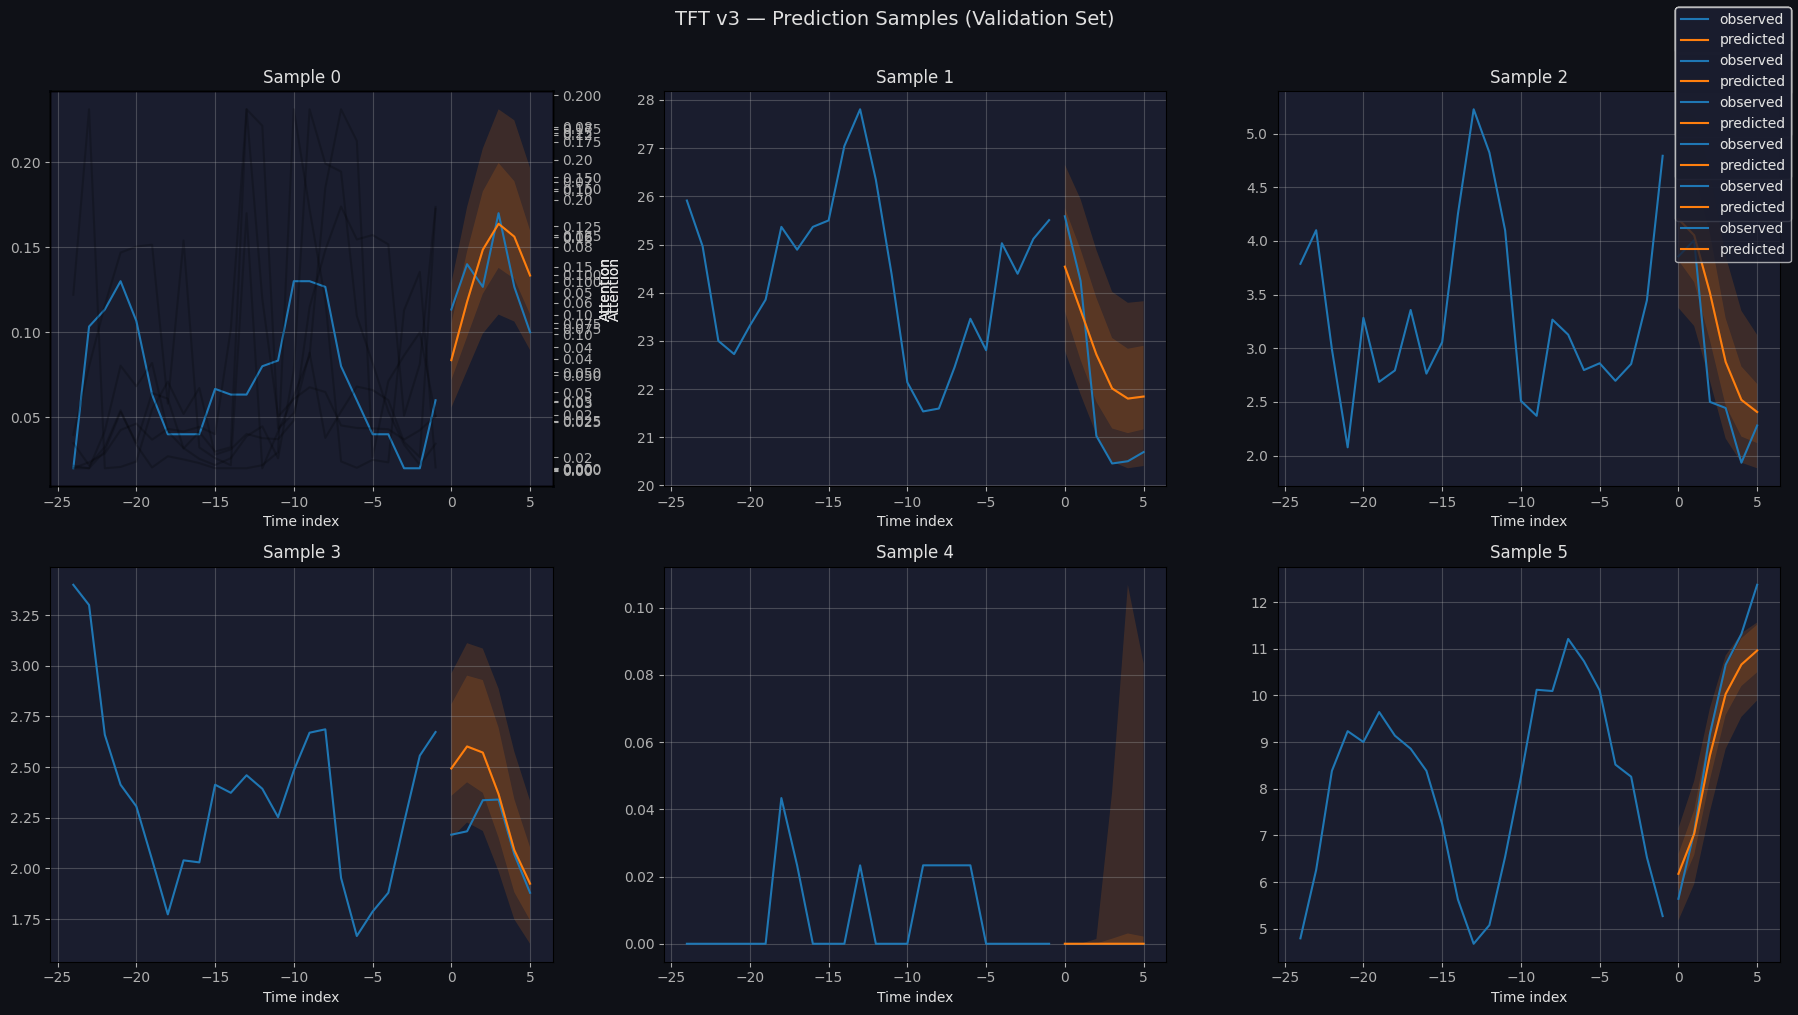

In [30]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 13 — VISUALIZE PREDICTIONS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d2e',
    'text.color': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#b0b0b0', 'ytick.color': '#b0b0b0',
})

# Plot 6 prediction samples
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, ax in enumerate(axes.flatten()):
    try:
        best_model.plot_prediction(
            raw_preds.x, raw_preds.output, idx=i, ax=ax,
        )
        ax.set_title(f'Sample {i}')
        ax.grid(alpha=0.3)
    except Exception:
        ax.set_visible(False)

plt.suptitle('TFT v3 — Prediction Samples (Validation Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

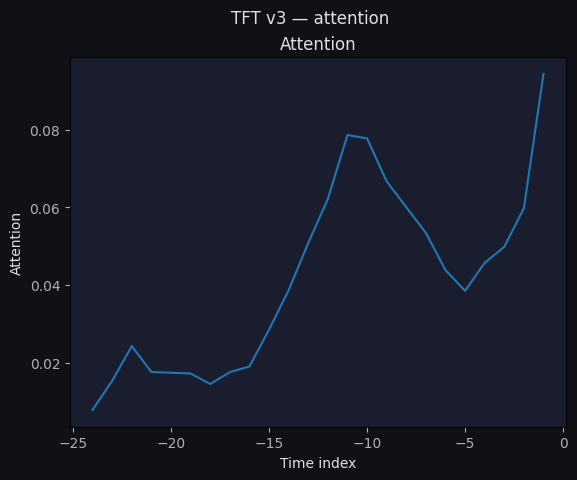

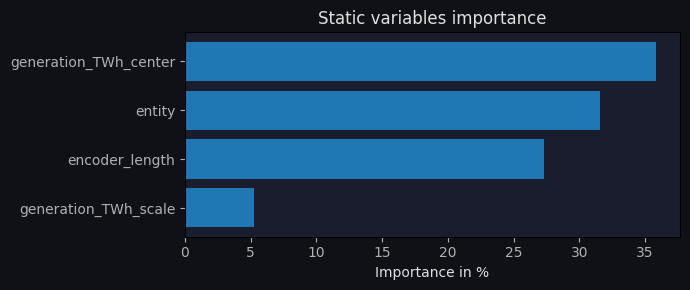

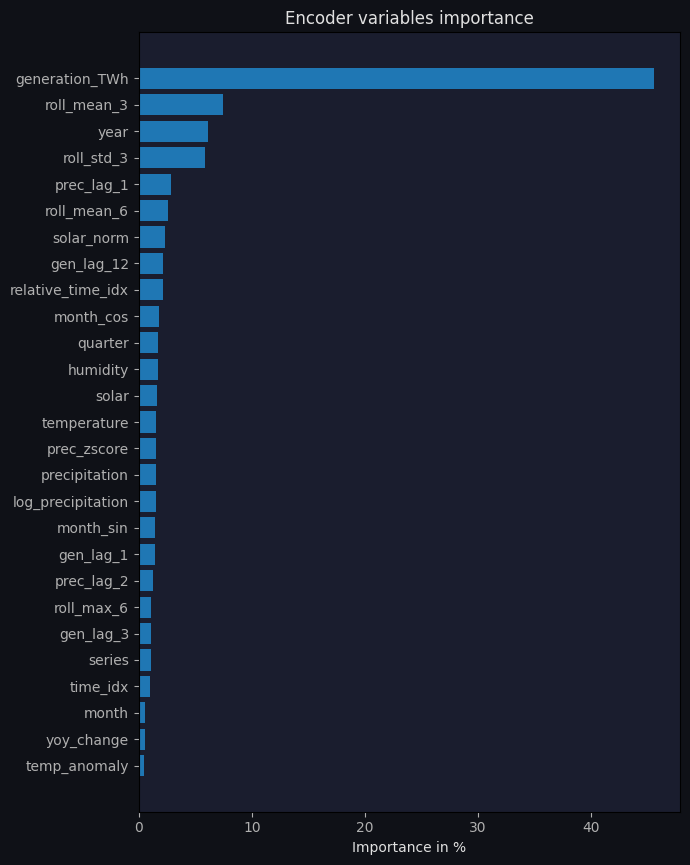

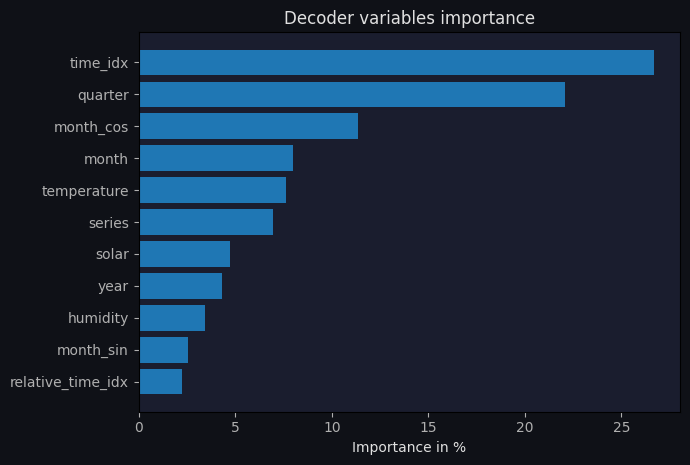

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


📊 Encoder Variable Importance (top 10):
humidity        68.810043
gen_lag_3       11.199633
month_cos        9.257933
roll_mean_3      8.880466
temp_anomaly     4.266826
gen_lag_12       3.854027
yoy_change       3.565452
gen_lag_1        3.282806
temperature      3.218364
month            2.652512


In [32]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 14 — INTERPRETABILITY: Variable Importance
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
interpretation = best_model.interpret_output(
    raw_preds.output, reduction='sum'
)
figs = best_model.plot_interpretation(interpretation)
for title, fig in figs.items():
    if hasattr(fig, 'suptitle'):      # đảm bảo là Figure thật
        fig.suptitle(f'TFT v3 — {title}', fontsize=12)
        plt.tight_layout()
        plt.show()

# In top features
print('\n📊 Encoder Variable Importance (top 10):')
enc = interpretation.get('encoder_variables')
if enc is not None:
    names = training.reals
    imp   = pd.Series(enc.numpy(), index=names[:len(enc)])
    print(imp.sort_values(ascending=False).head(10).to_string())

In [33]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 15 — TRAINING LOSS CURVE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Đọc log từ TensorBoard
import glob
log_base = str(BASE_DIR / 'lightning_logs')
event_files = glob.glob(log_base + '/**/events.out*', recursive=True)

try:
    from tensorboard.backend.event_file_loader import EventFileLoader
    train_losses, val_losses = [], []
    for ef in event_files:
        loader = EventFileLoader(ef)
        for event in loader.Load():
            for v in event.summary.value:
                if v.tag == 'train_loss_epoch':
                    train_losses.append(v.simple_value)
                if v.tag == 'val_loss':
                    val_losses.append(v.simple_value)

    if train_losses or val_losses:
        fig, ax = plt.subplots(figsize=(13, 5))
        if train_losses:
            ax.plot(train_losses, label='Train Loss', color='#4fc3f7', linewidth=2)
        if val_losses:
            ax.plot(val_losses, label='Val Loss', color='#f06292', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('QuantileLoss')
        ax.set_title('Training & Validation Loss Curve')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print('Không tìm thấy loss events trong log.')
except ImportError:
    pass

print(f'\n📊 Xem Training Curve đầy đủ trong TensorBoard:')
print(f'   tensorboard --logdir "{log_base}"')


📊 Xem Training Curve đầy đủ trong TensorBoard:
   tensorboard --logdir "C:\Users\ADMIN\Downloads\MODEL_TFT\lightning_logs"


In [34]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 16 — TỔNG KẾT & NEXT STEPS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('╔══════════════════════════════════════════════════════════════╗')
print('║                     KẾT QUẢ TRAINING                        ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Best val_loss : {checkpoint_callback.best_model_score:.6f}                        ║')
print(f'║  Epoch dừng   : {trainer.current_epoch}                                    ║')
print(f'║  MAE          : {mae:.4f} TWh                               ║')
print(f'║  RMSE         : {rmse:.4f} TWh                              ║')
print(f'║  SMAPE        : {smape:.2f}%                                ║')
print(f'║  WAPE         : {wape:.2f}%                                 ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Best checkpoint : tft_v3_best.ckpt                         ║')
print(f'║  Config JSON     : tft_v3_config.json                       ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  NEXT STEPS — Transfer Learning sang VN:                     ║')
print('║  1. Load: TemporalFusionTransformer                          ║')
print('║           .load_from_checkpoint("tft_v3_best.ckpt")          ║')
print('║  2. Tạo TimeSeriesDataSet từ vn_tft_ready.csv                ║')
print('║  3. Freeze encoder → Fine-tune với LR = 3e-5                 ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║                     KẾT QUẢ TRAINING                        ║
╠══════════════════════════════════════════════════════════════╣
║  Best val_loss : 0.497805                        ║
║  Epoch dừng   : 17                                    ║
║  MAE          : 0.6865 TWh                               ║
║  RMSE         : 1.1726 TWh                              ║
║  SMAPE        : 28.33%                                ║
║  WAPE         : 12.58%                                 ║
╠══════════════════════════════════════════════════════════════╣
║  Best checkpoint : tft_v3_best.ckpt                         ║
║  Config JSON     : tft_v3_config.json                       ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT STEPS — Transfer Learning sang VN:                     ║
║  1. Load: TemporalFusionTransformer                          ║
║           .load_from_checkpoint("tft_v3_best.ckpt")          ║
║  2

In [35]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 17 — [UTILITY] VERIFY CHECKPOINT
# Chạy cell này sau khi restart notebook để kiểm tra checkpoint
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def verify_checkpoint(ckpt_path):
    """Load và in thông tin checkpoint."""
    path = Path(ckpt_path)
    if not path.exists():
        print(f'❌ Không tìm thấy: {ckpt_path}')
        return

    ckpt = torch.load(str(path), map_location='cpu')
    hp   = ckpt.get('hyper_parameters', {})
    cbs  = ckpt.get('callbacks', {})
    val_loss = None
    for k, v in cbs.items():
        if 'ModelCheckpoint' in str(k):
            val_loss = v.get('best_model_score', None)

    size_mb = path.stat().st_size / 1024 / 1024
    print(f'✅ Checkpoint: {path.name} ({size_mb:.1f} MB)')
    print(f'   Epoch        : {ckpt.get("epoch", "N/A")}')
    print(f'   Global step  : {ckpt.get("global_step", "N/A")}')
    print(f'   Best val_loss: {val_loss}')
    print(f'   Hidden size  : {hp.get("hidden_size", "N/A")}')
    print(f'   LR           : {hp.get("learning_rate", "N/A")}')
    return ckpt

# Kiểm tra best checkpoint
BEST_CKPT = Path(r'C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint') / 'tft_v3_best.ckpt'
_ = verify_checkpoint(BEST_CKPT)

✅ Checkpoint: tft_v3_best.ckpt (18.6 MB)
   Epoch        : 4
   Global step  : 1030
   Best val_loss: 0.4978051483631134
   Hidden size  : 128
   LR           : 0.0003
